In [1]:
from pathlib import Path
from typing import Union
import pandas as pd
import numpy as np
from scipy import stats

from statsmodels.stats.proportion import proportions_ztest

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Plotting style
plt.style.use("seaborn-v0_8-darkgrid")

In [2]:
# Use pathlib for robust path handling
BASE_DIR = Path.cwd().parent 
PROCESSED_DATA_DIR = BASE_DIR / "data_processed"
CONFIG_DIR = BASE_DIR / "config"
MODEL_DIR = BASE_DIR / "models"
BRFSS_HARMONIZED_CLEAN_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024_cleaned.zip"
RECODED_CONFIG_FILE = CONFIG_DIR / "VALUE_RECODED_TEXT_MAP.json"

RANDOM_STATE = 42

In [3]:
def read_zipped_csv(
    zip_path: Union[str, Path],
    **read_csv_kwargs
) -> pd.DataFrame:
    """
    Read a single-CSV .zip file into a pandas DataFrame.

    Parameters
    ----------
    zip_path : str or Path
        Path to the .zip file (containing exactly one CSV, or a CSV
        with the same name as the zip).
    **read_csv_kwargs :
        Any extra keyword args passed through to pandas.read_csv
        (e.g. sep, dtype, parse_dates).

    Returns
    -------
    pd.DataFrame
    """
    zip_path = Path(zip_path)
    # For a single CSV in the zip, this is enough:
    return pd.read_csv(zip_path, compression="zip", **read_csv_kwargs)

In [4]:
df_raw = read_zipped_csv(BRFSS_HARMONIZED_CLEAN_ZIP_FILE)
print(f"Initial data loaded with {df_raw.shape[0]} rows. and columns: {df_raw.shape[1]}")
print(f"Years covered: {sorted(df_raw['YEAR'].unique())}")

Initial data loaded with 3101950 rows. and columns: 27
Years covered: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [5]:
# Data loaded successfully - 3.1 million respondents across 2015-2024
import json

# Load recoding map for pandemic flag labels
with open(RECODED_CONFIG_FILE, 'r') as f:
    full_map = json.load(f)

pandemic_map = full_map.get("PANDEMIC_FLAG", {})
age_group_map = full_map.get("IS_YOUNG_ADULT", {})

# Verify data structure
print(f"Pandemic flag values: {sorted(df_raw['PANDEMIC_FLAG'].dropna().unique())}")
print(f"Pandemic flag mapping: {pandemic_map}")
print(f"Age group values: {sorted(df_raw['IS_YOUNG_ADULT'].dropna().unique())}")
print(f"Age group mapping: {age_group_map}")

Pandemic flag values: [0, 1, 2]
Pandemic flag mapping: {'0': 'Pre-Pandemic', '1': 'Pandemic', '2': 'Post-Pandemic'}
Age group values: [0, 1]
Age group mapping: {'0': '30+', '1': '18-29'}


In [6]:
# ---------------------------------------------------------
# YEAR-BY-YEAR PANDEMIC IMPACT BREAKDOWN
# ---------------------------------------------------------

print("=" * 80)
print("YEAR-BY-YEAR ANALYSIS: Pandemic Impact Trajectory")
print("=" * 80)

yearly_analysis = []

for year in sorted(df_raw['YEAR'].unique()):
    df_year = df_raw[df_raw['YEAR'] == year]
    
    diabetes_count = (df_year['DIABETES'] == 1).sum()
    total_n = len(df_year)
    prevalence = (diabetes_count / total_n) * 100
    
    # Determine if pre-pandemic or pandemic
    if year <= 2019:
        period = "Pre-Pandemic"
    else:
        period = "Pandemic" if year <= 2021 else "Post-Pandemic"
    
    yearly_analysis.append({
        'Year': year,
        'Period': period,
        'Cases': diabetes_count,
        'N': total_n,
        'Prevalence %': round(prevalence, 2),
        'Sample %': round(total_n / len(df_raw) * 100, 1)
    })

yearly_df = pd.DataFrame(yearly_analysis)

display(yearly_df.style.hide(axis="index"))

# Calculate period-specific statistics
pre_pand_prev = yearly_df[yearly_df['Period'] == 'Pre-Pandemic']['Prevalence %'].mean()
pand_prev = yearly_df[yearly_df['Period'] == 'Pandemic']['Prevalence %'].mean()
post_pand_prev = yearly_df[yearly_df['Period'] == 'Post-Pandemic']['Prevalence %'].mean()

print(f"Period-Specific Averages:")
print(f"  Pre-Pandemic (2015-2019): {pre_pand_prev:.2f}%")
print(f"  Pandemic (2020-2021):     {pand_prev:.2f}%")
print(f"  Post-Pandemic (2022-2024): {post_pand_prev:.2f}%")

print(f"Change from Pre-Pandemic:")
print(f"  → Pandemic period: {pand_prev - pre_pand_prev:.2f} pp change")
print(f"  → Post-Pandemic period: {post_pand_prev - pre_pand_prev:.2f} pp change")

YEAR-BY-YEAR ANALYSIS: Pandemic Impact Trajectory


Year,Period,Cases,N,Prevalence %,Sample %
2015,Pre-Pandemic,51932,310660,16.720000,10.000000
2016,Pre-Pandemic,58888,335972,17.530000,10.800000
2017,Pre-Pandemic,54632,319640,17.090000,10.300000
2018,Pre-Pandemic,54495,308115,17.690000,9.900000
2019,Pre-Pandemic,51375,297444,17.270000,9.600000
2020,Pandemic,47013,286182,16.430000,9.200000
2021,Pandemic,51484,307489,16.740000,9.900000
2022,Post-Pandemic,54607,313832,17.400000,10.100000
2023,Post-Pandemic,52820,301476,17.520000,9.700000
2024,Post-Pandemic,58237,321140,18.130000,10.400000


Period-Specific Averages:
  Pre-Pandemic (2015-2019): 17.26%
  Pandemic (2020-2021):     16.59%
  Post-Pandemic (2022-2024): 17.68%
Change from Pre-Pandemic:
  → Pandemic period: -0.67 pp change
  → Post-Pandemic period: 0.42 pp change


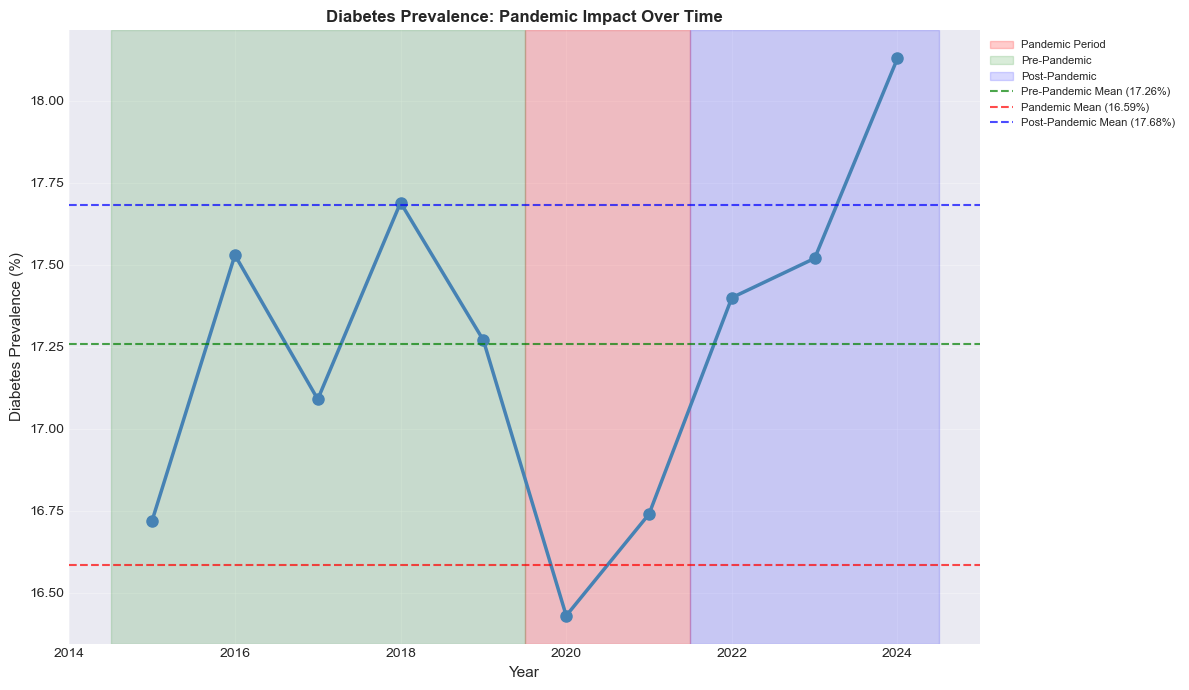

In [7]:
# ---------------------------------------------------------
# VISUALIZATION: Pandemic Impact Across Time
# ---------------------------------------------------------

fig, ax1 = plt.subplots(1, 1, figsize=(12, 7))

# Plot 1: Time series with period shading
ax1.plot(yearly_df['Year'], yearly_df['Prevalence %'], 'o-', linewidth=2.5, markersize=8, color='steelblue')

# Add vertical shading for pandemic period
ax1.axvspan(2019.5, 2021.5, alpha=0.2, color='red', label='Pandemic Period')
ax1.axvspan(2014.5, 2019.5, alpha=0.15, color='green', label='Pre-Pandemic')
ax1.axvspan(2021.5, 2024.5, alpha=0.15, color='blue', label='Post-Pandemic')

# Add horizontal line for pre-pandemic mean
ax1.axhline(y=pre_pand_prev, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Pre-Pandemic Mean ({pre_pand_prev:.2f}%)')
ax1.axhline(y=pand_prev, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Pandemic Mean ({pand_prev:.2f}%)')
ax1.axhline(y=post_pand_prev, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Post-Pandemic Mean ({post_pand_prev:.2f}%)')

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Diabetes Prevalence (%)', fontsize=11)
ax1.set_title('Diabetes Prevalence: Pandemic Impact Over Time', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
# Legend should be outside the plot area to avoid clutter
ax1.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [8]:
prevalence = (
    df_raw.groupby(["YEAR", "IS_YOUNG_ADULT"])["DIABETES"]
    .mean()
    .mul(100)
    .reset_index()
)
prevalence_pivot = (
    prevalence.pivot(index="YEAR", columns="IS_YOUNG_ADULT", values="DIABETES")
    .sort_index()
)

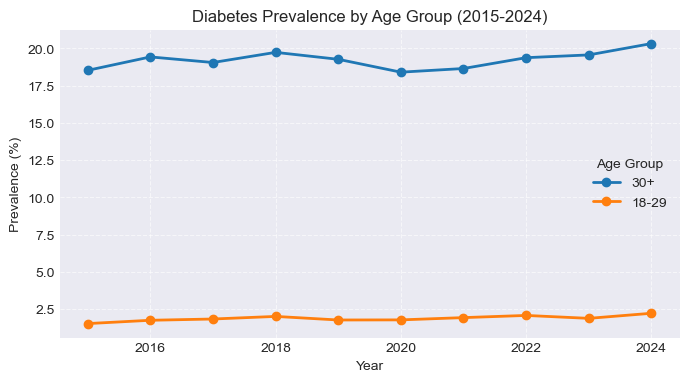

In [9]:
plt.figure(figsize=(8, 4))

for group in prevalence_pivot.columns:
    # Retrieve the text label from the map (e.g., "18-29", "30+")
    # Fallback to the group number if not found
    label_text = age_group_map.get(str(group), group)

    plt.plot(
        prevalence_pivot.index,
        prevalence_pivot[group],
        marker="o",
        linewidth=2,
        label=label_text,
    )

plt.title("Diabetes Prevalence by Age Group (2015-2024)")
plt.ylabel("Prevalence (%)")
plt.xlabel("Year")
plt.legend(title="Age Group")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

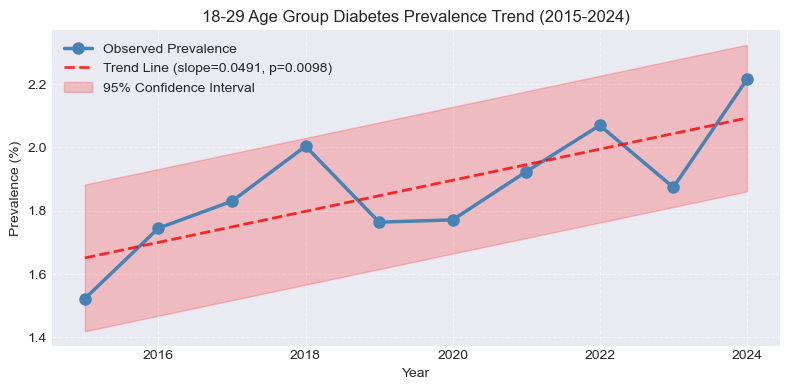

In [10]:



young_adult_prevalence = prevalence_pivot[1].copy()  # Group 1 = 18-29
years = young_adult_prevalence.index.values
years_numeric = np.arange(len(years))
prev_values = young_adult_prevalence.values
slope, intercept, r_value, p_value_regression, std_err = stats.linregress(years_numeric, prev_values)

plt.figure(figsize=(8, 4))

# Plot actual prevalence data
plt.plot(years, prev_values, marker="o", linewidth=2.5, markersize=8, 
         label="Observed Prevalence", color="steelblue")

# Calculate fitted values for regression line
fitted_values = slope * years_numeric + intercept
plt.plot(years, fitted_values, linewidth=2, linestyle="--", 
         label=f"Trend Line (slope={slope:.4f}, p={p_value_regression:.4f})", 
         color="red", alpha=0.8)

# Shade confidence interval (95%)
residuals = prev_values - fitted_values
std_residuals = np.std(residuals)
conf_interval = 1.96 * std_residuals
plt.fill_between(years, fitted_values - conf_interval, fitted_values + conf_interval, 
                alpha=0.2, color="red", label="95% Confidence Interval")

plt.title("18-29 Age Group Diabetes Prevalence Trend (2015-2024)")
plt.ylabel("Prevalence (%)")
plt.xlabel("Year")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

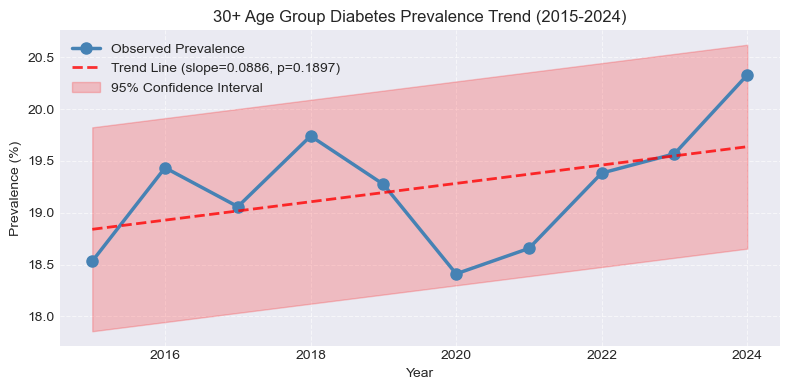

In [11]:
# Plot the prevalence trend for the 30+ group as done for the 18-29 group
older_adult_prevalence = prevalence_pivot[0].copy()  # Group
years = older_adult_prevalence.index.values
years_numeric = np.arange(len(years))
prev_values = older_adult_prevalence.values
slope, intercept, r_value, p_value_regression, std_err = stats.linregress(years_numeric, prev_values)

plt.figure(figsize=(8, 4))

# Plot actual prevalence data
plt.plot(years, prev_values, marker="o", linewidth=2.5, markersize=8, 
         label="Observed Prevalence", color="steelblue")

# Calculate fitted values for regression line
fitted_values = slope * years_numeric + intercept
plt.plot(years, fitted_values, linewidth=2, linestyle="--", 
         label=f"Trend Line (slope={slope:.4f}, p={p_value_regression:.4f})", 
         color="red", alpha=0.8)

# Shade confidence interval (95%)
residuals = prev_values - fitted_values
std_residuals = np.std(residuals)
conf_interval = 1.96 * std_residuals
plt.fill_between(years, fitted_values - conf_interval, fitted_values + conf_interval, 
                alpha=0.2, color="red", label="95% Confidence Interval")

plt.title("30+ Age Group Diabetes Prevalence Trend (2015-2024)")
plt.ylabel("Prevalence (%)")
plt.xlabel("Year")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [12]:
import imageio
import io
from PIL import Image

# Create a list to store frames for GIF
frames = []

# ============================================================================
# FRAME 1: Age Group Trends
# ============================================================================
fig1 = plt.figure(figsize=(10, 6))
ax1 = fig1.add_subplot(111)

for group in prevalence_pivot.columns:
    label_text = age_group_map.get(str(group), group)
    ax1.plot(
        prevalence_pivot.index,
        prevalence_pivot[group],
        marker="o",
        linewidth=2.5,
        markersize=8,
        label=label_text,
    )

ax1.set_title("Diabetes Prevalence by Age Group (2015-2024)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Prevalence (%)", fontsize=11)
ax1.set_xlabel("Year", fontsize=11)
ax1.legend(title="Age Group", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

# Convert figure to image and add to frames
fig1.canvas.draw()
image1 = Image.frombytes('RGB', fig1.canvas.get_width_height(), fig1.canvas.tostring_rgb())
frames.append(image1)
plt.close(fig1)

# ============================================================================
# FRAME 2: 30+ Age Group Regression Trend
# ============================================================================
older_adult_prevalence = prevalence_pivot[0].copy()  # Group 0 = 30+
years = older_adult_prevalence.index.values
years_numeric = np.arange(len(years))
prev_values = older_adult_prevalence.values
slope, intercept, r_value, p_value_regression, std_err = stats.linregress(years_numeric, prev_values)

fig2 = plt.figure(figsize=(10, 6))
ax2 = fig2.add_subplot(111)

# Plot actual prevalence data
ax2.plot(years, prev_values, marker="o", linewidth=2.5, markersize=8, 
         label="Observed Prevalence", color="steelblue")

# Calculate fitted values for regression line
fitted_values = slope * years_numeric + intercept
ax2.plot(years, fitted_values, linewidth=2, linestyle="--", 
         label=f"Trend Line (slope={slope:.4f}, p={p_value_regression:.4f})", 
         color="red", alpha=0.8)

# Shade confidence interval (95%)
residuals = prev_values - fitted_values
std_residuals = np.std(residuals)
conf_interval = 1.96 * std_residuals
ax2.fill_between(years, fitted_values - conf_interval, fitted_values + conf_interval, 
                alpha=0.2, color="red", label="95% Confidence Interval")

ax2.set_title("30+ Age Group Diabetes Prevalence Trend (2015-2024)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Prevalence (%)", fontsize=11)
ax2.set_xlabel("Year", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend(loc="best", fontsize=10)
plt.tight_layout()

# Convert figure to image and add to frames
fig2.canvas.draw()
image2 = Image.frombytes('RGB', fig2.canvas.get_width_height(), fig2.canvas.tostring_rgb())
frames.append(image2)
plt.close(fig2)

# ============================================================================
# FRAME 3: 18-29 Age Group Regression Trend
# ============================================================================
young_adult_prevalence = prevalence_pivot[1].copy()  # Group 1 = 18-29
years = young_adult_prevalence.index.values
years_numeric = np.arange(len(years))
prev_values = young_adult_prevalence.values
slope, intercept, r_value, p_value_regression, std_err = stats.linregress(years_numeric, prev_values)

fig3 = plt.figure(figsize=(10, 6))
ax3 = fig3.add_subplot(111)

# Plot actual prevalence data
ax3.plot(years, prev_values, marker="o", linewidth=2.5, markersize=8, 
         label="Observed Prevalence", color="steelblue")

# Calculate fitted values for regression line
fitted_values = slope * years_numeric + intercept
ax3.plot(years, fitted_values, linewidth=2, linestyle="--", 
         label=f"Trend Line (slope={slope:.4f}, p={p_value_regression:.4f})", 
         color="red", alpha=0.8)

# Shade confidence interval (95%)
residuals = prev_values - fitted_values
std_residuals = np.std(residuals)
conf_interval = 1.96 * std_residuals
ax3.fill_between(years, fitted_values - conf_interval, fitted_values + conf_interval, 
                alpha=0.2, color="red", label="95% Confidence Interval")

ax3.set_title("18-29 Age Group Diabetes Prevalence Trend (2015-2024)", fontsize=12, fontweight='bold')
ax3.set_ylabel("Prevalence (%)", fontsize=11)
ax3.set_xlabel("Year", fontsize=11)
ax3.grid(True, linestyle="--", alpha=0.6)
ax3.legend(loc="best", fontsize=10)
plt.tight_layout()

# Convert figure to image and add to frames
fig3.canvas.draw()
image3 = Image.frombytes('RGB', fig3.canvas.get_width_height(), fig3.canvas.tostring_rgb())
frames.append(image3)
plt.close(fig3)

# ============================================================================
# Save as GIF
# ============================================================================
gif_path = "diabetes_trends_animation.gif"
frames[0].save(
    gif_path, 
    save_all=True, 
    append_images=frames[1:], 
    duration=10000,  # 2 seconds per frame
    loop=0  # Infinite loop
)
print(f"GIF saved to: {gif_path}")
print(f"GIF contains {len(frames)} frames")


GIF saved to: diabetes_trends_animation.gif
GIF contains 3 frames


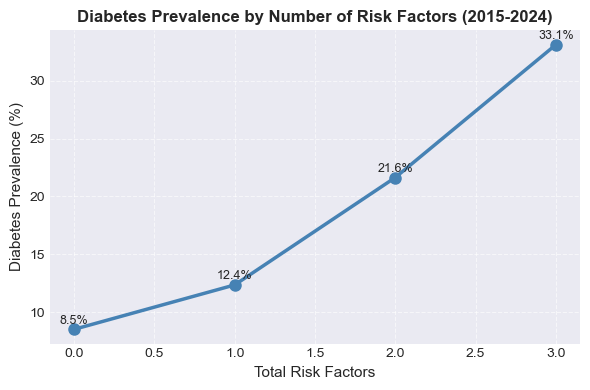


Diabetes Prevalence by Risk Factor Count:
  0 risk factors: 8.54%
  1 risk factors: 12.37%
  2 risk factors: 21.64%
  3 risk factors: 33.10%


In [13]:
# Plot diabetes prevalence by total risk factors
risk_prevalence = df_raw.groupby("TOTAL_RISK_FACTORS")["DIABETES"].mean() * 100

plt.figure(figsize=(6, 4))
plt.plot(risk_prevalence.index, risk_prevalence.values, marker="o", linewidth=2.5, markersize=8, color="steelblue")
plt.title("Diabetes Prevalence by Number of Risk Factors (2015-2024)", fontsize=12, fontweight='bold')
plt.ylabel("Diabetes Prevalence (%)", fontsize=11)
plt.xlabel("Total Risk Factors", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)

# Add value labels on each point
for x, y in zip(risk_prevalence.index, risk_prevalence.values):
    plt.text(x, y + 0.5, f'{y:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nDiabetes Prevalence by Risk Factor Count:")
for risk_count, prevalence in risk_prevalence.items():
    print(f"  {int(risk_count)} risk factors: {prevalence:.2f}%")


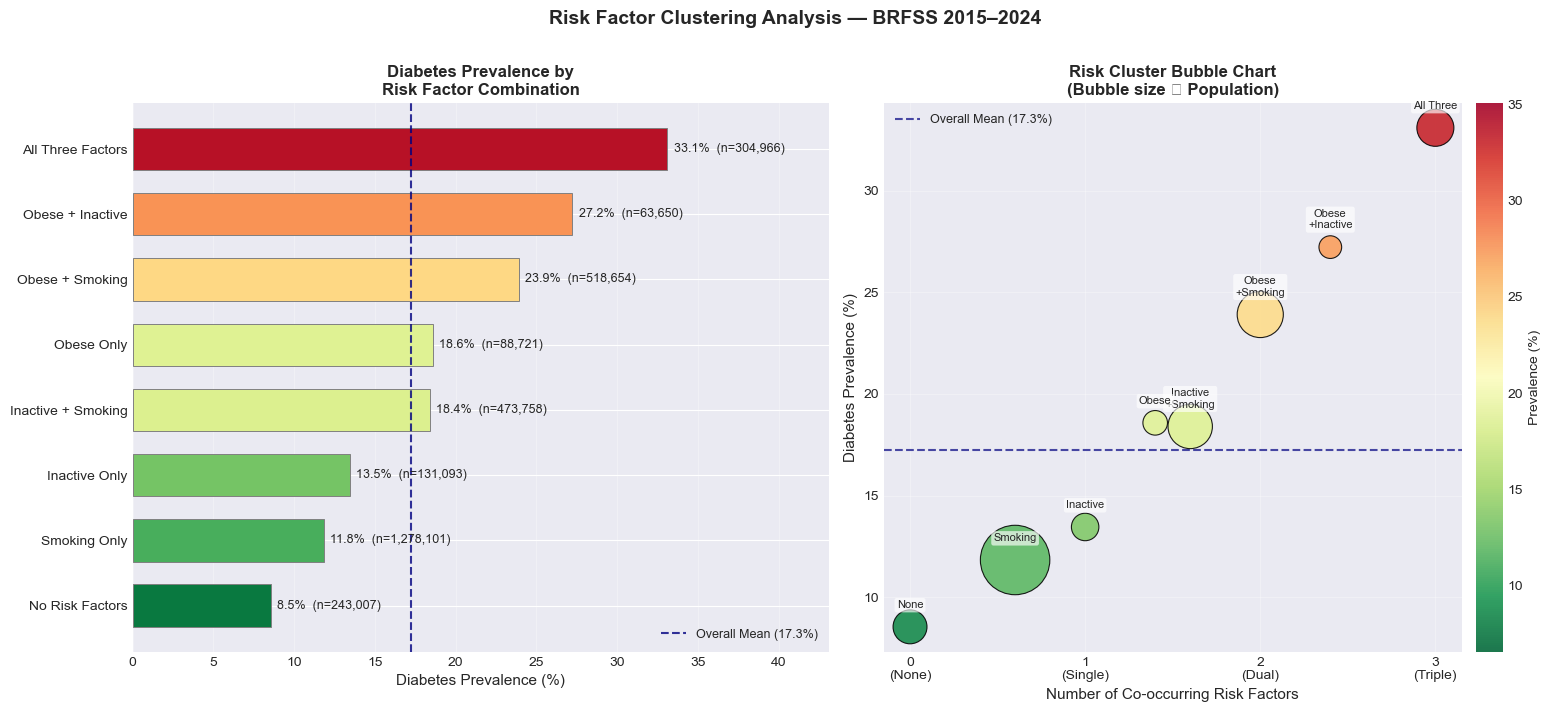


Risk Combination Summary:
       Combination  Risk Count  Prevalence (%)       N
 All Three Factors           3           33.10  304966
  Obese + Inactive           2           27.23   63650
   Obese + Smoking           2           23.91  518654
        Obese Only           1           18.58   88721
Inactive + Smoking           2           18.40  473758
     Inactive Only           1           13.45  131093
      Smoking Only           1           11.83 1278101
   No Risk Factors           0            8.54  243007


In [15]:

# ============================================================================
# RISK CLUSTERING PLOT
# Shows diabetes prevalence across all 8 combinations of the three lifestyle
# risk factors (Obesity × Inactivity × Smoking).
#   Panel A – Horizontal bar chart sorted by prevalence
#   Panel B – Bubble chart: x = risk-factor count, y = prevalence,
#             bubble size ∝ population
# ============================================================================
from collections import defaultdict

# ── 1. Resolve binary risk-flag columns ──────────────────────────────────────
if all(c in df_raw.columns for c in ['RISK_OBESITY', 'RISK_INACTIVE', 'RISK_SMOKING']):
    _ob = df_raw['RISK_OBESITY']
    _ia = df_raw['RISK_INACTIVE']
    _sm = df_raw['RISK_SMOKING']
else:
    _ob = (df_raw['BMICAT'] == 3).astype(int)
    _ia = (df_raw['EXERCISE'] == 0).astype(int)
    _sm = (df_raw['SMOKER'] >= 1).astype(int)

# ── 2. Compute stats for every combination ────────────────────────────────────
risk_combinations = {
    (0, 0, 0): 'No Risk Factors',
    (0, 0, 1): 'Smoking Only',
    (0, 1, 0): 'Inactive Only',
    (1, 0, 0): 'Obese Only',
    (0, 1, 1): 'Inactive + Smoking',
    (1, 0, 1): 'Obese + Smoking',
    (1, 1, 0): 'Obese + Inactive',
    (1, 1, 1): 'All Three Factors',
}

overall_mean = df_raw['DIABETES'].mean() * 100

combo_stats = []
for (ob, ia, sm), label in risk_combinations.items():
    mask = (_ob == ob) & (_ia == ia) & (_sm == sm)
    sub = df_raw.loc[mask, 'DIABETES']
    if len(sub) == 0:
        continue
    combo_stats.append({
        'label': label,
        'prevalence': sub.mean() * 100,
        'n': len(sub),
        'n_risk': ob + ia + sm,
    })

combo_df = (
    pd.DataFrame(combo_stats)
    .sort_values('prevalence', ascending=True)
    .reset_index(drop=True)
)

# ── 3. Build figure ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ─── Panel A: Horizontal bar chart ───────────────────────────────────────────
ax_bar = axes[0]
cmap_bar = plt.cm.RdYlGn_r
norm_bar = plt.Normalize(combo_df['prevalence'].min() - 1, combo_df['prevalence'].max() + 1)
bar_colors = [cmap_bar(norm_bar(v)) for v in combo_df['prevalence']]

bars = ax_bar.barh(
    combo_df['label'], combo_df['prevalence'],
    color=bar_colors, edgecolor='grey', linewidth=0.7, height=0.65
)

for bar, (_, row) in zip(bars, combo_df.iterrows()):
    ax_bar.text(
        bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
        f"{row['prevalence']:.1f}%  (n={row['n']:,.0f})",
        va='center', fontsize=9
    )

ax_bar.axvline(
    x=overall_mean, color='navy', linestyle='--', linewidth=1.5, alpha=0.8,
    label=f'Overall Mean ({overall_mean:.1f}%)'
)
ax_bar.set_xlabel('Diabetes Prevalence (%)', fontsize=11)
ax_bar.set_title('Diabetes Prevalence by\nRisk Factor Combination', fontsize=12, fontweight='bold')
ax_bar.legend(fontsize=9, loc='lower right')
ax_bar.grid(True, axis='x', alpha=0.3)
ax_bar.set_xlim(0, combo_df['prevalence'].max() + 10)

# ─── Panel B: Bubble chart ───────────────────────────────────────────────────
ax_bub = axes[1]

# Spread points with the same risk-count using horizontal jitter
risk_groups_idx = defaultdict(list)
for i, row in combo_df.iterrows():
    risk_groups_idx[row['n_risk']].append(i)

x_pos = np.zeros(len(combo_df))
for risk_val, indices in risk_groups_idx.items():
    count = len(indices)
    offsets = np.linspace(-0.2 * (count - 1), 0.2 * (count - 1), count) if count > 1 else [0.0]
    for j, idx in enumerate(indices):
        x_pos[idx] = risk_val + offsets[j]

# Normalise bubble size: largest → 2 500 pt², smallest → 150 pt²
n_vals = combo_df['n'].values
sizes = 150 + (n_vals / n_vals.max()) * 2350

sc = ax_bub.scatter(
    x_pos, combo_df['prevalence'],
    s=sizes, c=combo_df['prevalence'],
    cmap='RdYlGn_r',
    vmin=combo_df['prevalence'].min() - 2,
    vmax=combo_df['prevalence'].max() + 2,
    edgecolors='black', linewidths=0.8, alpha=0.88, zorder=3
)

# Annotate each bubble with combination label
bubble_labels = {
    'No Risk Factors': 'None',
    'Smoking Only': 'Smoking',
    'Inactive Only': 'Inactive',
    'Obese Only': 'Obese',
    'Inactive + Smoking': 'Inactive\n+Smoking',
    'Obese + Smoking': 'Obese\n+Smoking',
    'Obese + Inactive': 'Obese\n+Inactive',
    'All Three Factors': 'All Three',
}
for idx, row in combo_df.iterrows():
    ax_bub.annotate(
        bubble_labels.get(row['label'], row['label']),
        xy=(x_pos[idx], row['prevalence']),
        xytext=(0, 12), textcoords='offset points',
        fontsize=8, ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.65, lw=0)
    )

cbar = plt.colorbar(sc, ax=ax_bub, pad=0.02)
cbar.set_label('Prevalence (%)', fontsize=10)

ax_bub.axhline(
    y=overall_mean, color='navy', linestyle='--', linewidth=1.5,
    alpha=0.7, label=f'Overall Mean ({overall_mean:.1f}%)'
)
ax_bub.set_xticks([0, 1, 2, 3])
ax_bub.set_xticklabels(['0\n(None)', '1\n(Single)', '2\n(Dual)', '3\n(Triple)'], fontsize=10)
ax_bub.set_xlabel('Number of Co-occurring Risk Factors', fontsize=11)
ax_bub.set_ylabel('Diabetes Prevalence (%)', fontsize=11)
ax_bub.set_title('Risk Cluster Bubble Chart\n(Bubble size ∝ Population)', fontsize=12, fontweight='bold')
ax_bub.legend(fontsize=9, loc='upper left')
ax_bub.grid(True, alpha=0.3, zorder=1)

fig.suptitle('Risk Factor Clustering Analysis — BRFSS 2015–2024',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\nRisk Combination Summary:")
print(combo_df[['label', 'n_risk', 'prevalence', 'n']]
      .rename(columns={'label': 'Combination', 'n_risk': 'Risk Count',
                       'prevalence': 'Prevalence (%)', 'n': 'N'})
      .sort_values('Prevalence (%)', ascending=False)
      .to_string(index=False, float_format=lambda x: f"{x:.2f}"))
